<a href="https://colab.research.google.com/github/Adhityayusuf/PCVK26_09_M.Adhitya-Yusuf-Al-Ayyubi/blob/main/P3_Week3_09.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ===== SEL IDENTITAS - JANGAN DIHAPUS, HARUS SEL PERTAMA =====
import sys, platform, hashlib, datetime, zoneinfo

NAMA = 'M.Adhitya Yusuf Al-Ayyubi'
NIM = '244107020045'

N = int(NIM[-3:])
PARAM = {
    'b' : (N % 61) + 20,
    'a' : round(1.0 + (N % 9) / 10, 1),
    'c' : (N % 20) + 30,
    'gamma': round(0.4 + (N % 6) * 0.25, 2),
    'bit' : (N % 6) + 2,
}
waktu = datetime.datetime.now(zoneinfo.ZoneInfo('Asia/Jakarta'))

print('NAMA :', NAMA)
print('NIM  :', NIM, '| N =', N)
for k, v in PARAM.items():
    print('%-6s: %s' % (k, v))
print('WAKTU :', waktu.strftime('%Y-%m-%d %H:%M:%S %Z'))
print('SISTEM:', sys.version.split()[0], platform.platform())
kunci = NIM + '|' + waktu.strftime('%Y-%m-%d')
print('TOKEN :', hashlib.sha256(kunci.encode()).hexdigest()[:16])

NAMA : M.Adhitya Yusuf Al-Ayyubi
NIM  : 244107020045 | N = 45
b     : 65
a     : 1.0
c     : 35
gamma : 1.15
bit   : 5
WAKTU : 2026-09-18 18:46:35 WIB
SISTEM: 3.13.15 Linux-6.6.122+-x86_64-with-glibc2.39
TOKEN : 0e3e64b1e9570612


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


 Mengubah tingkat kecerahan citra 
----------------------------------
Masukkan nilai kecerahan: 30


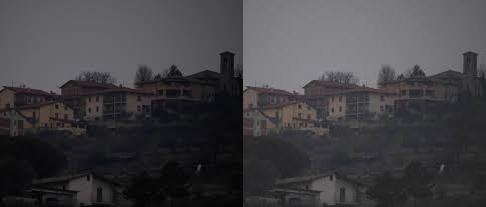

In [ ]:
import cv2 as cv
import numpy as np
from google.colab.patches import cv2_imshow

print(' Mengubah tingkat kecerahan citra ')
print('----------------------------------')
try:
    brightness = int(input('Masukkan nilai kecerahan: '))
except ValueError:
    print('Error, not a number')

original = cv.imread('/content/drive/MyDrive/pcvk/houses.jpg')
brightness_image = np.zeros(original.shape, original.dtype)

for y in range(original.shape[0]):
    for x in range(original.shape[1]):
        for c in range(original.shape[2]):
            brightness_image[y,x,c] = np.clip(original[y,x,c] + brightness, 0, 255)

final_frame = cv.hconcat((original, brightness_image))
cv2_imshow(final_frame)

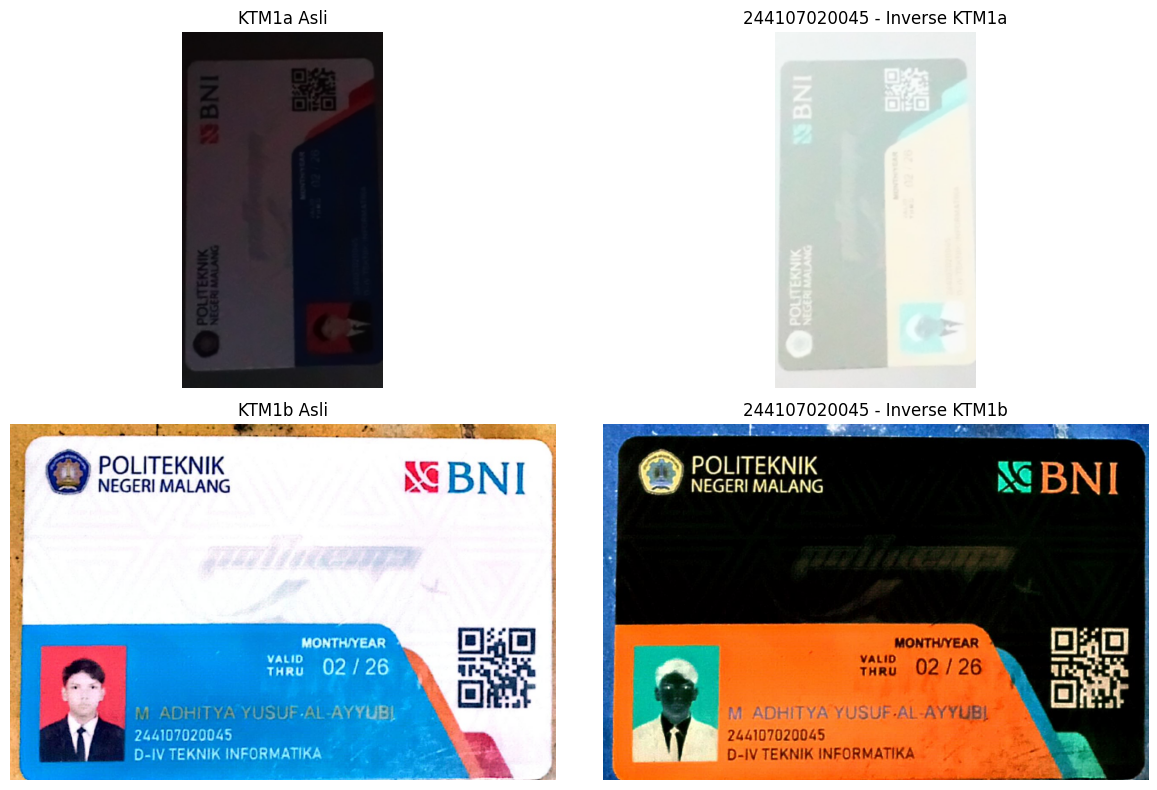

In [ ]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

path_ktm1a = '/content/drive/MyDrive/pcvk/KTM1a.jpg'
path_ktm1b = '/content/drive/MyDrive/pcvk/KTM1b.jpg'

ktm1a = cv.cvtColor(cv.imread(path_ktm1a), cv.COLOR_BGR2RGB)
ktm1b = cv.cvtColor(cv.imread(path_ktm1b), cv.COLOR_BGR2RGB)

inv_1a = 255 - ktm1a
inv_1b = 255 - ktm1b

fig, ax = plt.subplots(2, 2, figsize=(12, 8))

ax[0,0].imshow(ktm1a)
ax[0,0].set_title('KTM1a Asli')
ax[0,0].axis('off')

ax[0,1].imshow(inv_1a)
ax[0,1].set_title(f'{NIM} - Inverse KTM1a')
ax[0,1].axis('off')

ax[1,0].imshow(ktm1b)
ax[1,0].set_title('KTM1b Asli')
ax[1,0].axis('off')

ax[1,1].imshow(inv_1b)
ax[1,1].set_title(f'{NIM} - Inverse KTM1b')
ax[1,1].axis('off')

plt.tight_layout()
plt.show()

Citra negatif KTM1a tampak pucat dan berkabut karena foto aslinya sangat gelap. Saat di-inverse dengan rumus $255 - f(x), hampir seluruh piksel tersebut berbalik menjadi sangat terang (mendekati 255). Akibatnya, gambar kehilangan detail dan tertutup warna putih karena tidak ada rentang warna penyeimbang.Sebaliknya, KTM1b aslinya memiliki pencahayaan dan sebaran piksel yang merata. Saat di-inverse, nilai piksel hanya bertukar posisi (terang menjadi gelap, gelap menjadi terang), tetapi jarak selisih antar warnanya tetap terjaga. Hal ini membuat batas antar objek tetap sehingga kontrasnya tidak hilang.

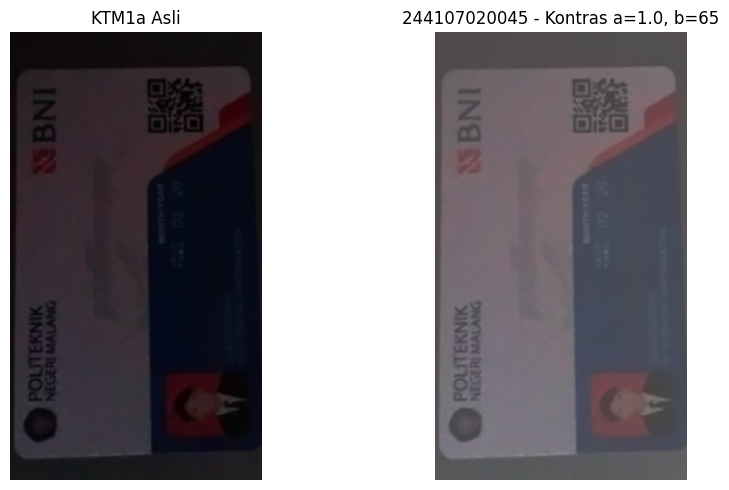

In [ ]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

path_ktm1a = '/content/drive/MyDrive/pcvk/KTM1a.jpg'
ktm1a = cv.cvtColor(cv.imread(path_ktm1a), cv.COLOR_BGR2RGB)

a = PARAM['a']
b = PARAM['b']

kontras_1a = np.clip(a * ktm1a.astype(float) + b, 0, 255).astype(np.uint8)

fig, ax = plt.subplots(1, 2, figsize=(10, 5))

ax[0].imshow(ktm1a)
ax[0].set_title('KTM1a Asli')
ax[0].axis('off')

ax[1].imshow(kontras_1a)
ax[1].set_title(f'{NIM} - Kontras a={a}, b={b}')
ax[1].axis('off')

plt.tight_layout()
plt.show()

 Mengubah tingkat kecerahan citra dengan Transformasi Log 
----------------------------------------------------------
Masukkan nilai kecerahan: 35


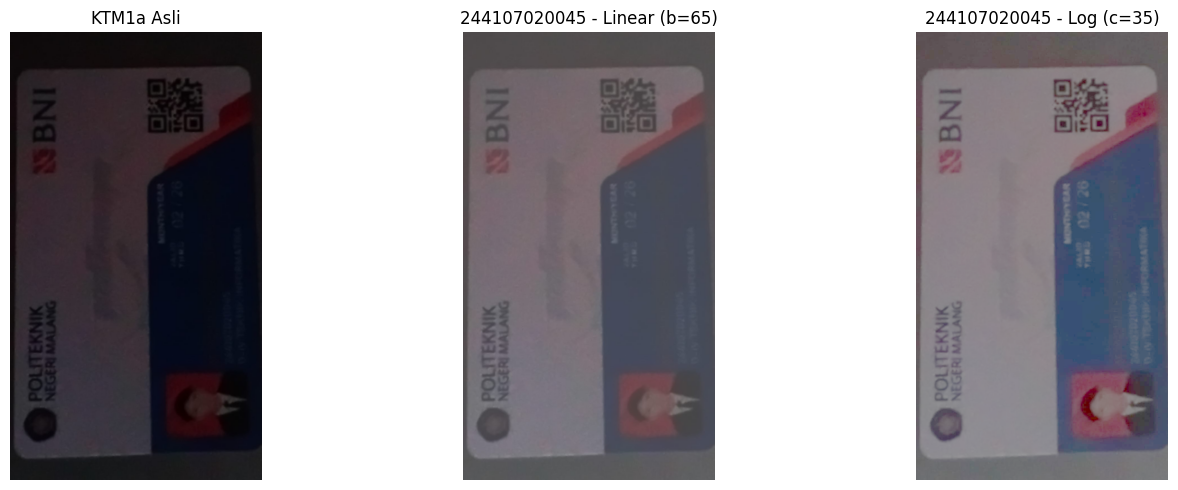

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

b = PARAM['b']
c = PARAM['c']

print(' Mengubah tingkat kecerahan citra dengan Transformasi Log ')
print('----------------------------------------------------------')
print(f'Masukkan nilai kecerahan: {c}')

linear_1a = np.clip(ktm1a.astype(float) + b, 0, 255).astype(np.uint8)

log_1a = c * np.log1p(ktm1a.astype(float))
log_1a = np.clip(log_1a, 0, 255).astype(np.uint8)

fig, ax = plt.subplots(1, 3, figsize=(15, 5))

ax[0].imshow(ktm1a)
ax[0].set_title('KTM1a Asli')
ax[0].axis('off')

ax[1].imshow(linear_1a)
ax[1].set_title(f'{NIM} - Linear (b={b})')
ax[1].axis('off')

ax[2].imshow(log_1a)
ax[2].set_title(f'{NIM} - Log (c={c})')
ax[2].axis('off')

plt.tight_layout()
plt.show()

**1. Metode yang membuat NIM lebih terbaca:**   
Metode Logarithmi. Pada metode Linear, gambar hanya berubah menjadi abu-abu pudar sehingga teks ikut tersamar. Sedangkan Logarithmic menaikkan intensitas bagian yang gelap dengan lebih kuat, sehingga teks NIM bisa terekspos dan jauh lebih jelas.

**2. Bagian yang mengalami clipping (putih penuh):**  

Linear:Hampir tidak ada clipping. Karena foto aslinya sangat gelap, penambahan nilai konstan (65) cuma membuat warnanya jadi abu-abu, belum sampai menyentuh batas putih (255).     
Logarithmic:Clipping terjadi di latar putih kartu, latar merah pas foto, dan logo BNI. Rumus logaritma menaikkan nilai terlalu ekstrem, sehingga area tersebut langsung mentok di angka 255 (putih penuh).

Jadual Min dan Sisihan Piawai (Standard Deviation):
---------------------------------------------
Kaedah          | Min        | Sisihan   
---------------------------------------------
Averaging       | 197.13     | 70.06     
Lightness       | 197.67     | 69.10     
Luminance       | 191.52     | 76.50     
---------------------------------------------


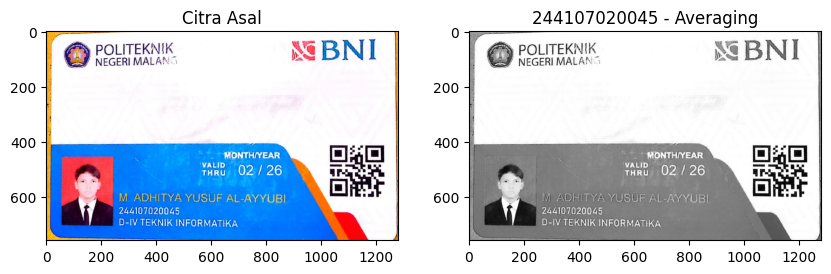

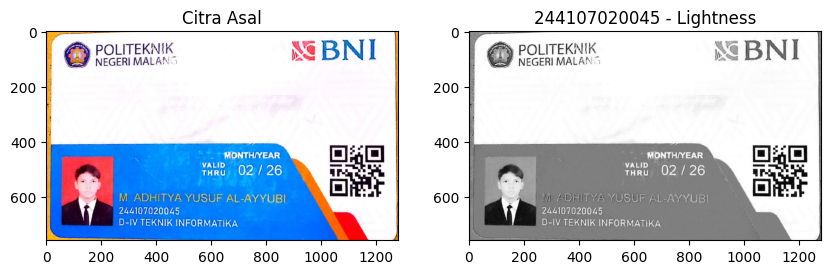

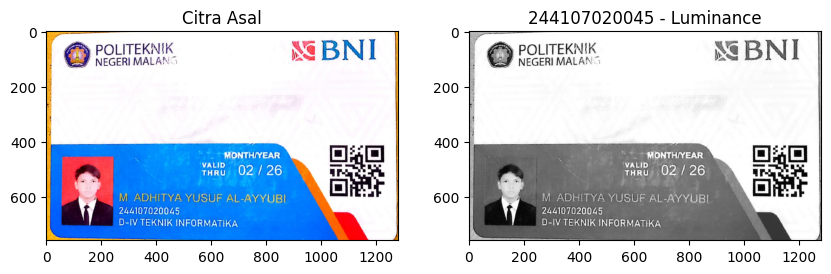

In [ ]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

path_ktm1c = '/content/drive/MyDrive/pcvk/KTM1c.jpg'
ktm1c = cv.cvtColor(cv.imread(path_ktm1c), cv.COLOR_BGR2RGB)

R = ktm1c[:,:,0].astype(float)
G = ktm1c[:,:,1].astype(float)
B = ktm1c[:,:,2].astype(float)

gray_avg = np.round((R + G + B) / 3).astype(np.uint8)

maks = np.max(ktm1c, axis=2).astype(float)
mins = np.min(ktm1c, axis=2).astype(float)
gray_light = np.round((maks + mins) / 2).astype(np.uint8)

gray_lum = np.round(0.21 * R + 0.72 * G + 0.07 * B).astype(np.uint8)

print("Jadual Min dan Sisihan Piawai (Standard Deviation):")
print("-" * 45)
print(f"{'Kaedah':<15} | {'Min':<10} | {'Sisihan':<10}")
print("-" * 45)
print(f"{'Averaging':<15} | {np.mean(gray_avg):<10.2f} | {np.std(gray_avg):<10.2f}")
print(f"{'Lightness':<15} | {np.mean(gray_light):<10.2f} | {np.std(gray_light):<10.2f}")
print(f"{'Luminance':<15} | {np.mean(gray_lum):<10.2f} | {np.std(gray_lum):<10.2f}")
print("-" * 45)

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].imshow(ktm1c); ax[0].set_title('Citra Asal'); ax[0].axis('on')
ax[1].imshow(gray_avg, cmap='gray'); ax[1].set_title(f'{NIM} - Averaging'); ax[1].axis('on')
plt.show()

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].imshow(ktm1c); ax[0].set_title('Citra Asal'); ax[0].axis('on')
ax[1].imshow(gray_light, cmap='gray'); ax[1].set_title(f'{NIM} - Lightness'); ax[1].axis('on')
plt.show()

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].imshow(ktm1c); ax[0].set_title('Citra Asal'); ax[0].axis('on')
ax[1].imshow(gray_lum, cmap='gray'); ax[1].set_title(f'{NIM} - Luminance'); ax[1].axis('on')
plt.show()

Metode Luminance memberikan pemisahan paling jelas antara teks dan latar kartu.

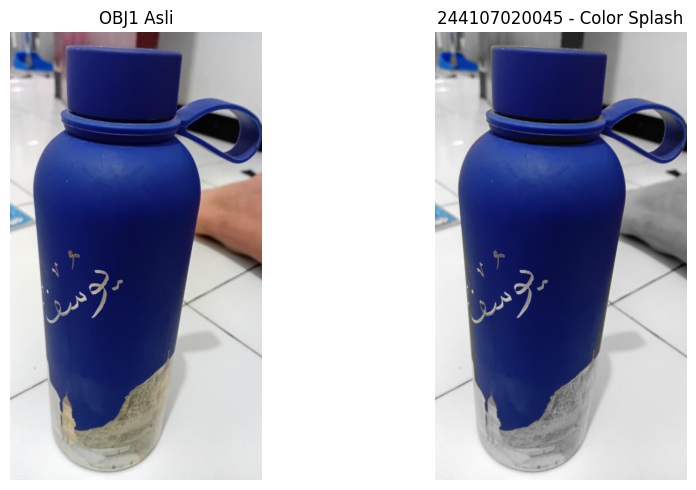

In [ ]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

path_obj = '/content/drive/MyDrive/pcvk/OBJ1.jpg'
img_bgr = cv.imread(path_obj)
img_rgb = cv.cvtColor(img_bgr, cv.COLOR_BGR2RGB)

img_hsv = cv.cvtColor(img_bgr, cv.COLOR_BGR2HSV)

img_gray = cv.cvtColor(img_bgr, cv.COLOR_BGR2GRAY)
img_gray_3c = cv.cvtColor(img_gray, cv.COLOR_GRAY2RGB)

lower_blue = np.array([100, 100, 50])
upper_blue = np.array([140, 255, 255])
mask_warna = cv.inRange(img_hsv, lower_blue, upper_blue)

hasil_splash = np.where(mask_warna[:,:,None] == 255, img_rgb, img_gray_3c)

fig, ax = plt.subplots(1, 2, figsize=(10, 5))

ax[0].imshow(img_rgb)
ax[0].set_title('OBJ1 Asli')
ax[0].axis('off')

ax[1].imshow(hasil_splash)
ax[1].set_title(f'{NIM} - Color Splash')
ax[1].axis('off')

plt.tight_layout()
plt.show()

**1. Rentang nilai HSV (Biru):**  
Batas bawah `[100, 100, 50]` dan batas atas `[140, 255, 255]`.

**2. Pengaruh jika rentang diperlebar:**   
Seleksi warna jadi bocor. Benda lain di background atau lantai yang warnanya agak kebiruan akan ikut terdeteksi sebagai biru, sehingga area tersebut gagal berubah menjadi hitam-putih.

**3. Pengaruh jika rentang dipersempit:**    
Warna botol biru akan terlihat belang-belang abu-abu. Ini terjadi karena bagian botol yang agak gelap atau terlalu terang tidak masuk ke dalam rentang seleksi, sehingga area tersebut ikut diubah menjadi hitam-putih.

 Gamma Correction pada citra 
-----------------------------
Masukkan nilai Gamma: 1.15


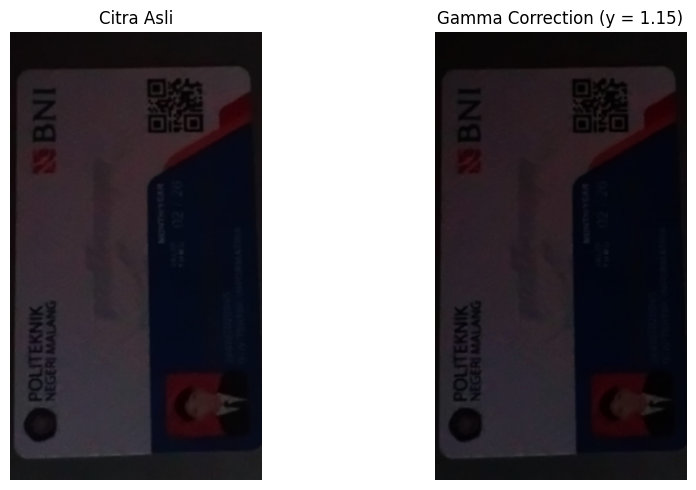

In [ ]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

path_ktm1a = '/content/drive/MyDrive/pcvk/KTM1a.jpg'
ktm1a = cv.cvtColor(cv.imread(path_ktm1a), cv.COLOR_BGR2RGB)

print(' Gamma Correction pada citra ')
print('-----------------------------')

try:
    gamma = float(input('Masukkan nilai Gamma: '))
    img_normal = ktm1a.astype(float) / 255.0
    gamma_corrected = np.clip(255 * (img_normal ** gamma), 0, 255).astype(np.uint8)
    fig, ax = plt.subplots(1, 2, figsize=(10, 5))

    ax[0].imshow(ktm1a)
    ax[0].set_title('Citra Asli')
    ax[0].axis('off')

    ax[1].imshow(gamma_corrected)
    ax[1].set_title(f'Gamma Correction (y = {gamma})')
    ax[1].axis('off')

    plt.tight_layout()
    plt.show()

except ValueError:
    print('Error, not a number')

 Gamma Correction pada citra 
-----------------------------
Masukkan nilai Gamma: 0.8


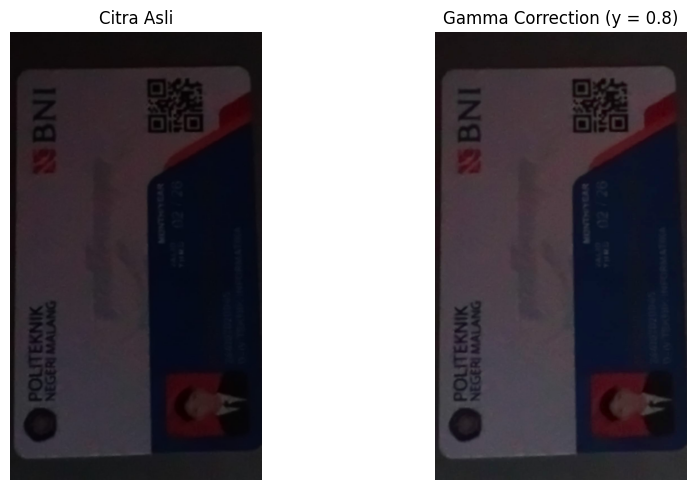

In [ ]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

path_ktm1a = '/content/drive/MyDrive/pcvk/KTM1a.jpg'
ktm1a = cv.cvtColor(cv.imread(path_ktm1a), cv.COLOR_BGR2RGB)

print(' Gamma Correction pada citra ')
print('-----------------------------')

try:
    gamma = float(input('Masukkan nilai Gamma: '))
    img_normal = ktm1a.astype(float) / 255.0
    gamma_corrected = np.clip(255 * (img_normal ** gamma), 0, 255).astype(np.uint8)
    fig, ax = plt.subplots(1, 2, figsize=(10, 5))

    ax[0].imshow(ktm1a)
    ax[0].set_title('Citra Asli')
    ax[0].axis('off')

    ax[1].imshow(gamma_corrected)
    ax[1].set_title(f'Gamma Correction (y = {gamma})')
    ax[1].axis('off')

    plt.tight_layout()
    plt.show()

except ValueError:
    print('Error, not a number')

 Gamma Correction pada citra 
-----------------------------
Masukkan nilai Gamma: 0.5


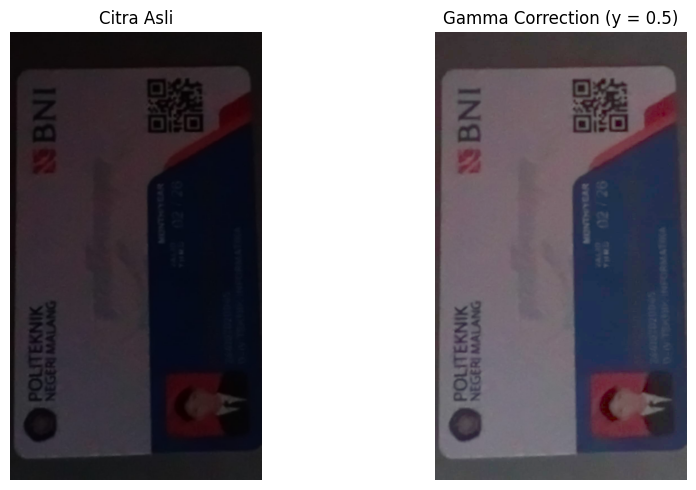

In [ ]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

path_ktm1a = '/content/drive/MyDrive/pcvk/KTM1a.jpg'
ktm1a = cv.cvtColor(cv.imread(path_ktm1a), cv.COLOR_BGR2RGB)

print(' Gamma Correction pada citra ')
print('-----------------------------')

try:
    gamma = float(input('Masukkan nilai Gamma: '))
    img_normal = ktm1a.astype(float) / 255.0
    gamma_corrected = np.clip(255 * (img_normal ** gamma), 0, 255).astype(np.uint8)
    fig, ax = plt.subplots(1, 2, figsize=(10, 5))

    ax[0].imshow(ktm1a)
    ax[0].set_title('Citra Asli')
    ax[0].axis('off')

    ax[1].imshow(gamma_corrected)
    ax[1].set_title(f'Gamma Correction (y = {gamma})')
    ax[1].axis('off')

    plt.tight_layout()
    plt.show()

except ValueError:
    print('Error, not a number')

 Gamma Correction pada citra 
-----------------------------
Masukkan nilai Gamma: 0.3


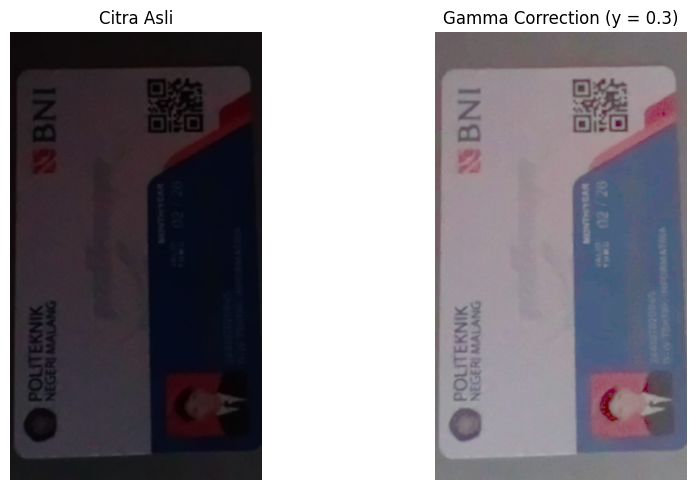

In [ ]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

path_ktm1a = '/content/drive/MyDrive/pcvk/KTM1a.jpg'
ktm1a = cv.cvtColor(cv.imread(path_ktm1a), cv.COLOR_BGR2RGB)

print(' Gamma Correction pada citra ')
print('-----------------------------')

try:
    gamma = float(input('Masukkan nilai Gamma: '))
    img_normal = ktm1a.astype(float) / 255.0
    gamma_corrected = np.clip(255 * (img_normal ** gamma), 0, 255).astype(np.uint8)
    fig, ax = plt.subplots(1, 2, figsize=(10, 5))

    ax[0].imshow(ktm1a)
    ax[0].set_title('Citra Asli')
    ax[0].axis('off')

    ax[1].imshow(gamma_corrected)
    ax[1].set_title(f'Gamma Correction (y = {gamma})')
    ax[1].axis('off')

    plt.tight_layout()
    plt.show()

except ValueError:
    print('Error, not a number')

 Gamma Correction pada citra 
-----------------------------
Masukkan nilai Gamma: 2.0


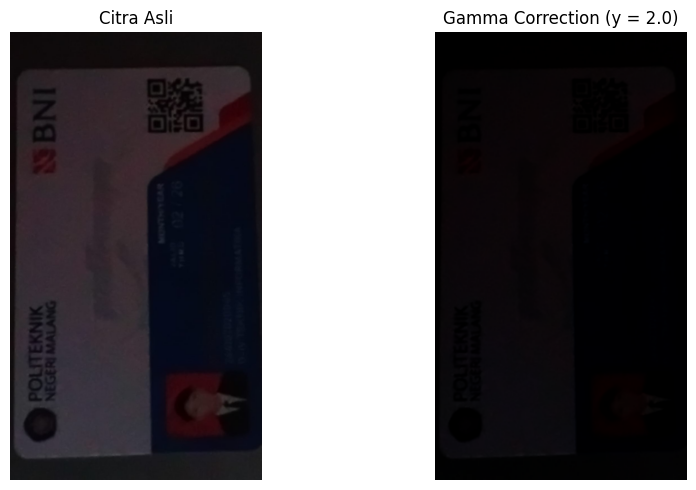

In [ ]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

path_ktm1a = '/content/drive/MyDrive/pcvk/KTM1a.jpg'
ktm1a = cv.cvtColor(cv.imread(path_ktm1a), cv.COLOR_BGR2RGB)

print(' Gamma Correction pada citra ')
print('-----------------------------')

try:
    gamma = float(input('Masukkan nilai Gamma: '))
    img_normal = ktm1a.astype(float) / 255.0
    gamma_corrected = np.clip(255 * (img_normal ** gamma), 0, 255).astype(np.uint8)
    fig, ax = plt.subplots(1, 2, figsize=(10, 5))

    ax[0].imshow(ktm1a)
    ax[0].set_title('Citra Asli')
    ax[0].axis('off')

    ax[1].imshow(gamma_corrected)
    ax[1].set_title(f'Gamma Correction (y = {gamma})')
    ax[1].axis('off')

    plt.tight_layout()
    plt.show()

except ValueError:
    print('Error, not a number')

**1. Nilai Gamma Terbaik:**   
Nilai gamma 0.3 adalah yang paling optimal karena mampu mencerahkan foto KTM1a yang gelap secara signifikan tanpa merusak detail teks.

**2. Alasan Nilai Terbaik Setiap Mahasiswa Berbeda:**   
Meskipun objek kartunya sama, kondisi saat pengambilan foto seperti tingkat cahaya ruangan, jenis kamera, jarak, dan bayangan membuat sebaran intensitas piksel awal tiap foto berbeda-beda, sehingga tingkat koreksi gamma yang dibutuhkan juga tidak sama.

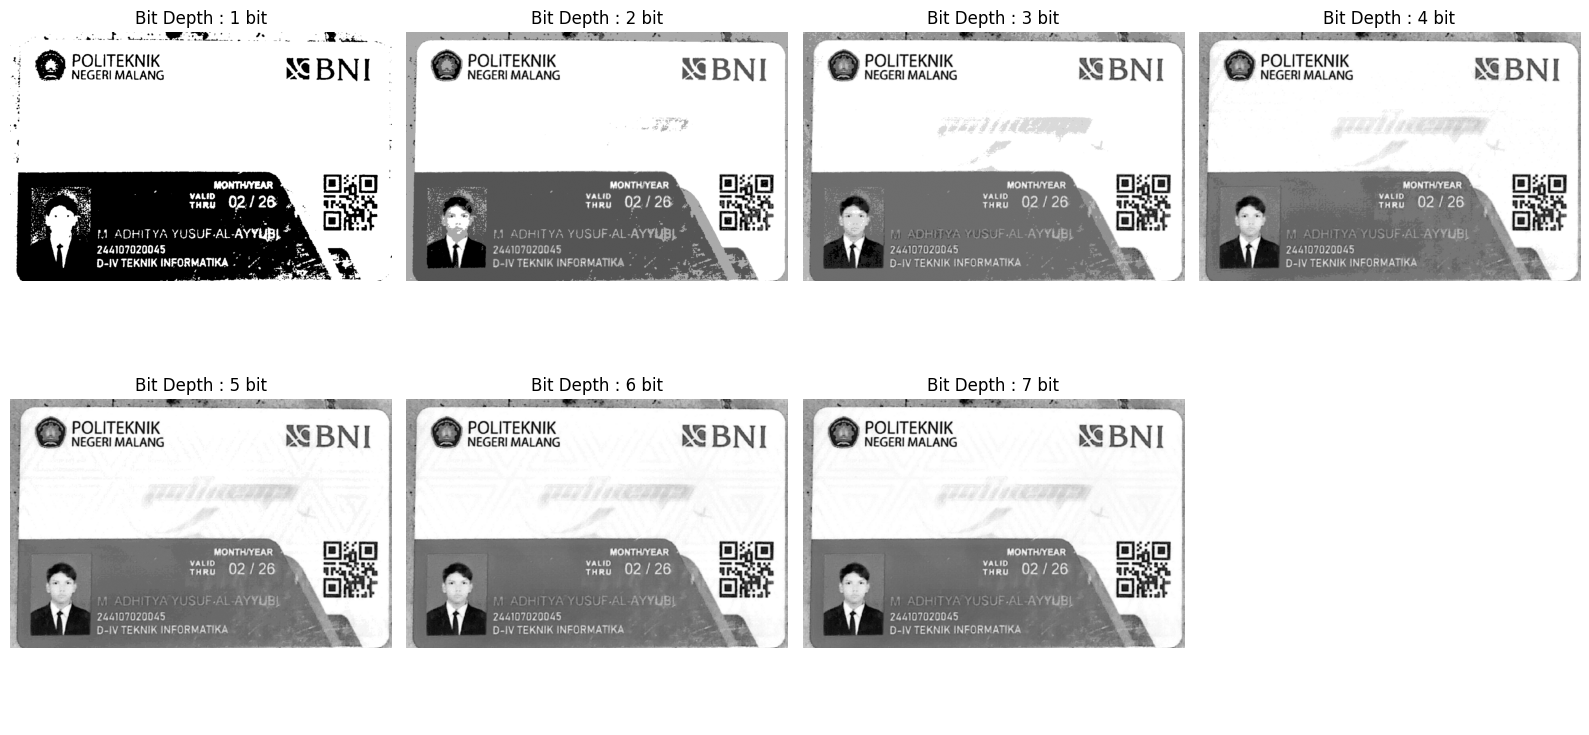

In [ ]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

path_ktm1b = '/content/drive/MyDrive/pcvk/KTM1b.jpg'
original = cv.imread(path_ktm1b, cv.IMREAD_GRAYSCALE)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.ravel()

for i, bit_depth in enumerate(range(1, 8)):
    level = 255 / (pow(2, bit_depth) - 1)
    depth_image = np.round(original / level) * level
    depth_image = depth_image.astype(np.uint8)
    axes[i].imshow(depth_image, cmap='gray')
    axes[i].set_title(f'Bit Depth : {bit_depth} bit')
    axes[i].axis('off')

axes[7].axis('off')
plt.tight_layout()
plt.show()

Nama dan NIM pada kartu masih terbaca mulai dari kedalaman 2 bit hingga 7 bit

Jumlah Citra    | Nilai PSNR (dB)
-----------------------------------
10              | 19.73          
20              | 19.84          
40              | 19.89          
80              | 19.92          
100             | 19.92          


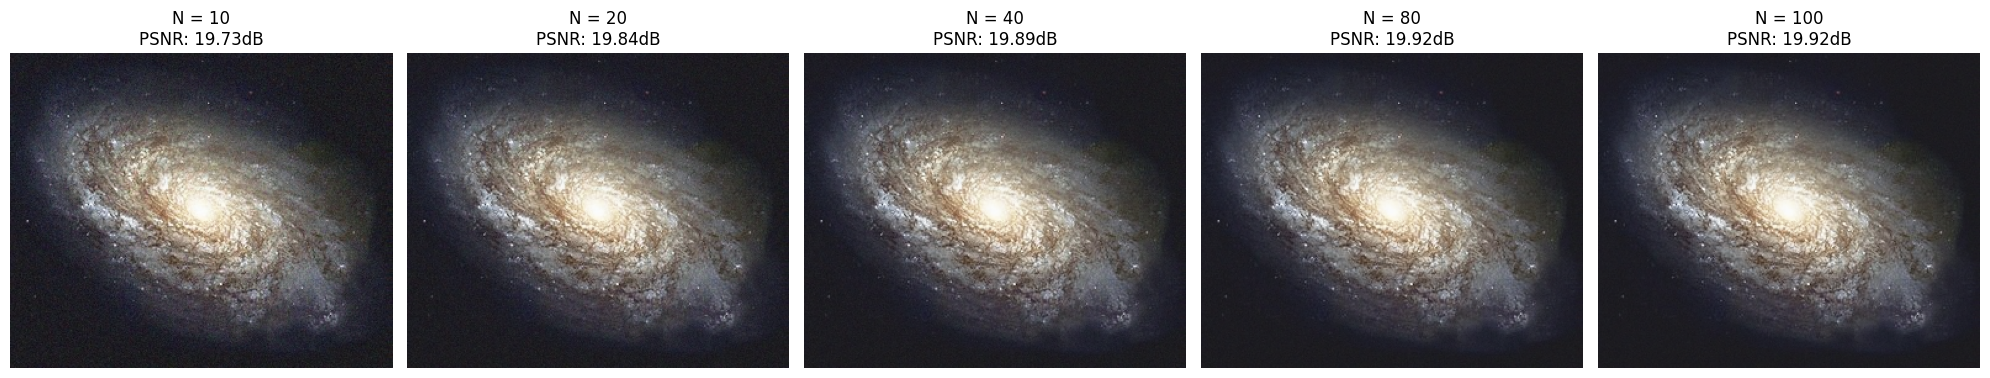

In [ ]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
import glob
from math import log10, sqrt

path_galaxy = '/content/drive/MyDrive/pcvk/galaxy.jpg'
original = cv.imread(path_galaxy)

cv_img = []
for img_path in glob.glob('/content/drive/MyDrive/pcvk/noises/*.jpg'):

    n = cv.imread(img_path)
    if n is not None:
        cv_img.append(n)

def hitung_psnr(img_asli, img_hasil):
    original_f = img_asli.astype(float)
    hasil_f = img_hasil.astype(float)
    mse = np.mean((original_f - hasil_f) ** 2)
    if mse == 0:
        return 100
    max_pixel = 255.0
    psnr = 20 * log10(max_pixel / sqrt(mse))
    return psnr

jumlah_list = [10, 20, 40, 80, 100]

print(f"{'Jumlah Citra':<15} | {'Nilai PSNR (dB)':<15}")
print("-" * 35)

fig, axes = plt.subplots(1, len(jumlah_list), figsize=(20, 4))

for idx, jml in enumerate(jumlah_list):
    subset = np.array(cv_img[:jml], dtype=float)
    avg_img = np.mean(subset, axis=0).astype(np.uint8)
    psnr_val = hitung_psnr(original, avg_img)
    print(f"{jml:<15} | {psnr_val:<15.2f}")
    axes[idx].imshow(cv.cvtColor(avg_img, cv.COLOR_BGR2RGB))
    axes[idx].set_title(f'N = {jml}\nPSNR: {psnr_val:.2f}dB')
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

* **Apakah peningkatan jumlah citra selalu memberikan peningkatan PSNR yang signifikan?**   
Tidak selalu. Kenaikan nilai PSNR sangat tinggi di awal, tetapi akan semakin melambat seiring bertambahnya jumlah citra.
* **Pada jumlah citra berapa peningkatan mulai tidak terlalu signifikan?**     
Mulai tidak terlalu signifikan pada rentang 40 ke 80 atau 100 citra karena nilainya sudah mulai stabil.
* **Kesimpulan:**     
Average Denoising efektif mengurangi Gaussian Noise. Namun, ada batas efisiensi di mana penambahan citra yang terlalu banyak tidak sebanding dengan peningkatan kualitasnya.

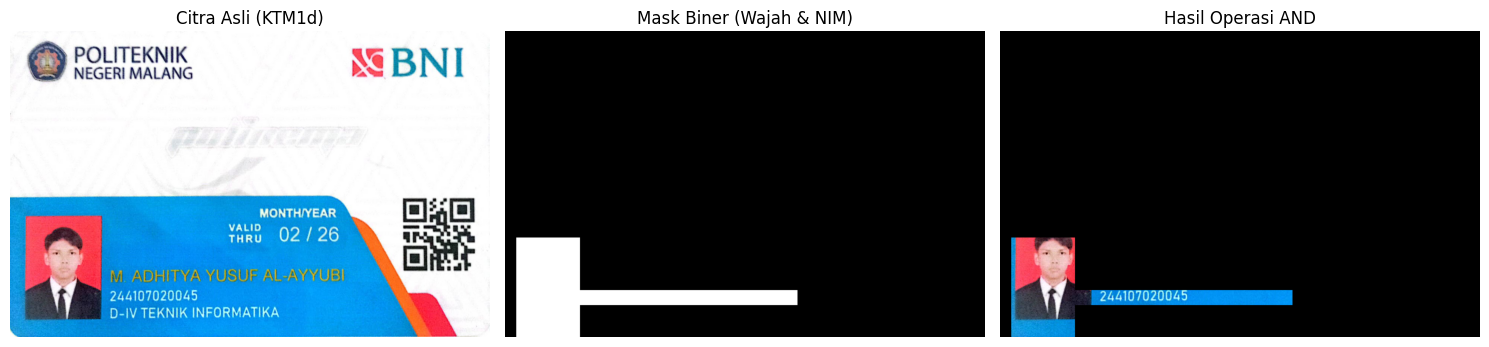

In [55]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

path_ktm = '/content/drive/MyDrive/pcvk/KTM1d.jpg'
img = cv.imread(path_ktm)
img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)
h, w, _ = img.shape
mask = np.zeros((h, w), dtype=np.uint8)
mask[550:850, 30:200] = 255
mask[690:730, 200:780] = 255
mask_3c = cv.merge([mask, mask, mask])
hasil_and = cv.bitwise_and(img_rgb, mask_3c)
fig, ax = plt.subplots(1, 3, figsize=(15, 5))

ax[0].imshow(img_rgb)
ax[0].set_title('Citra Asli (KTM1d)')
ax[0].axis('off')

ax[1].imshow(mask_3c)
ax[1].set_title('Mask Biner (Wajah & NIM)')
ax[1].axis('off')

ax[2].imshow(hasil_and)
ax[2].set_title('Hasil Operasi AND')
ax[2].axis('off')

plt.tight_layout()
plt.show()

mask[550:850, 30:200] = 255    
mask[690:730, 200:780] = 255

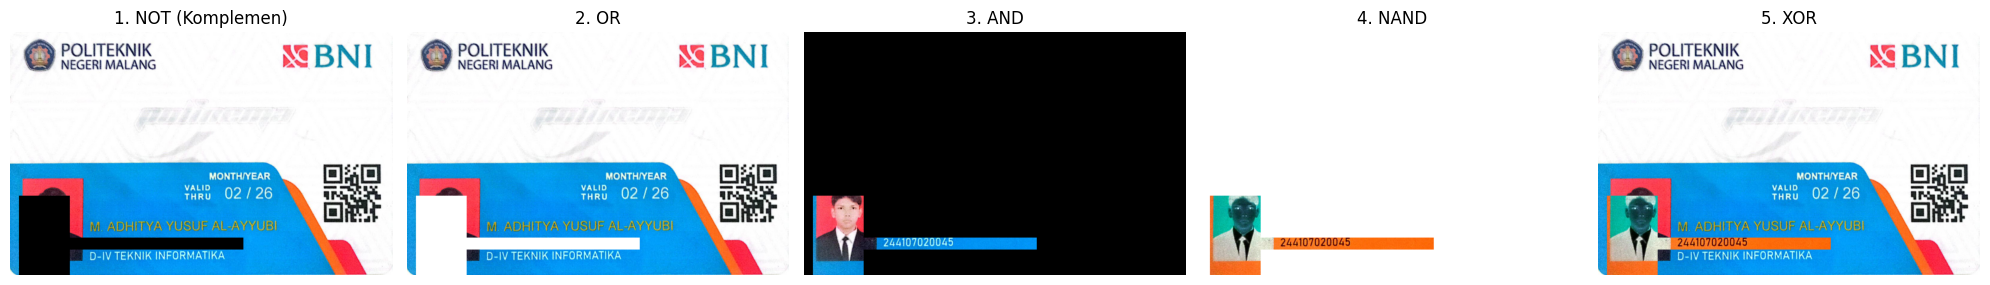

In [56]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

path_ktm = '/content/drive/MyDrive/pcvk/KTM1d.jpg'
img = cv.imread(path_ktm)
img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)
h, w, _ = img.shape

mask = np.zeros((h, w), dtype=np.uint8)
mask[550:850, 30:200] = 255
mask[690:730, 200:780] = 255
mask_3c = cv.merge([mask, mask, mask])

res_not  = cv.bitwise_not(mask_3c)
res_not_img = cv.bitwise_and(img_rgb, res_not)

res_or   = cv.bitwise_or(img_rgb, mask_3c)
res_and  = cv.bitwise_and(img_rgb, mask_3c)
res_nand = cv.bitwise_not(res_and)
res_xor  = cv.bitwise_xor(img_rgb, mask_3c)

operators = ['1. NOT (Komplemen)', '2. OR', '3. AND', '4. NAND', '5. XOR']
outputs   = [res_not_img, res_or, res_and, res_nand, res_xor]

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for i in range(5):
    axes[i].imshow(outputs[i])
    axes[i].set_title(operators[i])
    axes[i].axis('off')

plt.tight_layout()
plt.show()

* **NOT:** Membalikkan nilai piksel mask sehingga area wajah dan NIM tertutup warna hitam, sementara latar belakang kartu di luar mask tetap utuh.
* **OR:** Menggabungkan citra dengan mask, menghasilkan area kotak mask yang berubah menjadi putih penuh, sedangkan bagian luar tetap mempertahankan gambar aslinya.
* **AND:** Berfungsi sebagai penyaring yang hanya meloloskan bagian dalam kotak mask (wajah dan NIM), sementara area di luar kotak diubah menjadi hitam penuh.
* **NAND:** Merupakan kebalikan dari operator AND; area wajah dan NIM berubah menjadi hitam, sementara area latar belakang mengalami inversi warna.
* **XOR:** Menghasilkan efek inversi warna pada area mask akibat perbandingan bitwise eksklusif antara citra asli dan mask biner.

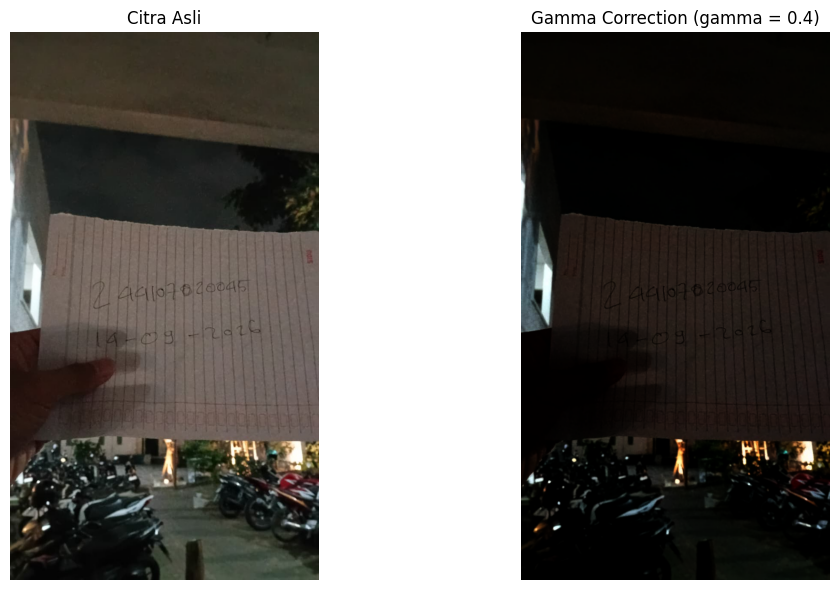

In [62]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
path_night = '/content/drive/MyDrive/pcvk/NIGHT1.jpg'
img = cv.imread(path_night)
img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)
gamma = 0.4
inv_gamma = 1.0 / gamma
table = np.array([((i / 255.0) ** inv_gamma) * 255 for i in np.arange(0, 256)]).astype("uint8")
img_gamma = cv.LUT(img_rgb, table)
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

ax[0].imshow(img_rgb)
ax[0].set_title('Citra Asli')
ax[0].axis('off')

ax[1].imshow(img_gamma)
ax[1].set_title(f'Gamma Correction (gamma = {gamma})')
ax[1].axis('off')

plt.tight_layout()
plt.show()

* **Alasan:** Efektif mencerahkan area gelap secara optimal tanpa membuat bagian terang menjadi silau, sehingga detail objek atau tulisan di malam hari tampak lebih jelas.    
* **Risiko:** Jika nilai gamma tidak pas, gambar bisa menjadi pudar, kontras berkurang, dan bintik-bintik akan semakin terlihat jelas.